# ⚽ Predicción del Campeón — Copa Mundial FIFA 2026
## Camino metodológico completo (v5 · validación temporal · base ESPN + Elo 1872–2026)

Este notebook presenta un modelo de **clasificación multinomial** (Victoria / Empate / Derrota) diseñado para predecir el resultado de partidos internacionales y realizar simulaciones de Monte Carlo para la Copa del Mundo 2026. 

**Puntos clave del diseño:**
* **Sin fuga de información:** Las variables son point-in-time / walk-forward y la validación es estrictamente temporal (`TimeSeriesSplit` + hold-out de 2025–26).
* **Variables simétricas:** Diferencias sin sesgo de localía (salvo para los anfitriones del torneo).
* **Datos:** 5,023 partidos (2019 → jun-2026) y Elo histórico desde 1872.

## 0 · Configuración

In [25]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); np.random.seed(42)
SEED = 42

# Mapeo de selecciones a banderas emoji para mejorar la estética de las tablas
FLAGS = {
    'Algeria': '🇩🇿', 'Argentina': '🇦🇷', 'Australia': '🇦🇺', 'Austria': '🇦🇹', 'Belgium': '🇧🇪',
    'Bosnia and Herzegovina': '🇧🇦', 'Brazil': '🇧🇷', 'Canada': '🇨🇦', 'Cape Verde': '🇨🇻',
    'Colombia': '🇨🇴', 'Croatia': '🇭🇷', 'Curaçao': '🇨🇼', 'Czech Republic': '🇨🇿', 'DR Congo': '🇨🇩',
    'Ecuador': '🇪🇨', 'Egypt': '🇪🇬', 'England': '🏴󠁧󠁢󠁥󠁮󠁧󠁿', 'France': '🇫🇷', 'Germany': '🇩🇪',
    'Ghana': '🇬🇭', 'Haiti': '🇭🇹', 'Iran': '🇮🇷', 'Iraq': '🇮🇶', 'Ivory Coast': '🇨🇮',
    'Japan': '🇯🇵', 'Jordan': '🇯🇴', 'Mexico': '🇲🇽', 'Morocco': '🇲🇦', 'Netherlands': '🇳🇱',
    'New Zealand': '🇳🇿', 'Norway': '🇳🇴', 'Panama': '🇵🇦', 'Paraguay': '🇵🇾', 'Portugal': '🇵🇹',
    'Qatar': '🇶🇦', 'Saudi Arabia': '🇸🇦', 'Scotland': '🏴󠁧󠁢󠁳󠁣󠁴󠁿', 'Senegal': '🇸🇳',
    'South Africa': '🇿🇦', 'South Korea': '🇰🇷', 'Spain': '🇪🇸', 'Sweden': '🇸🇪',
    'Switzerland': '🇨🇭', 'Tunisia': '🇹🇳', 'Turkey': '🇹🇷', 'United States': '🇺🇸',
    'Uruguay': '🇺🇾', 'Uzbekistan': '🇺🇿'
}

def add_flag(name):
    return f"{FLAGS.get(name, '')} {name}" if name in FLAGS else name

def style_table(df):
    df_styled = df.copy()
    # Aplicar banderas a las columnas que contienen nombres de selecciones
    for col in ['local', 'visita', 'Equipo', 'Selección', 'equipo_1', 'equipo_2']:
        if col in df_styled.columns:
            df_styled[col] = df_styled[col].map(add_flag)
            
    # Estilizado CSS elegante de la tabla
    styler = df_styled.style
    
    # Identificar columnas de probabilidades
    prob_cols = [col for col in df_styled.columns if col.startswith('P_') or col.startswith('P(') or 'proba' in col.lower() or 'probabilidad' in col.lower()]
    
    # Diccionario de formatos de visualización
    format_dict = {}
    for col in df_styled.columns:
        if col in prob_cols:
            format_dict[col] = '{:,.1%}'
        elif col in ['goles_esp_1', 'goles_esp_2']:
            format_dict[col] = '{:.2f}'
        elif col == 'dif (logit − poisson)':
            format_dict[col] = '{:+,.1%}'
            
    if format_dict:
        styler = styler.format(format_dict)
        
    styler = styler.set_properties(**{
        'font-family': 'Inter, system-ui, sans-serif',
        'padding': '10px 14px',
        'border-bottom': '1px solid #e2e8f0',
        'font-size': '13px'
    })
    
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#1e293b'),
            ('color', '#ffffff'),
            ('font-family', 'Inter, system-ui, sans-serif'),
            ('font-weight', '600'),
            ('padding', '10px 14px'),
            ('text-align', 'center'),
            ('border-bottom', '2px solid #cbd5e1')
        ]},
        {'selector': 'tr:nth-child(even)', 'props': [
            ('background-color', '#f8fafc')
        ]},
        {'selector': 'tr:hover', 'props': [
            ('background-color', '#f1f5f9'),
            ('transition', 'background-color 0.15s ease')
        ]}
    ])
    
    if prob_cols:
        styler = styler.background_gradient(subset=prob_cols, cmap='Blues')
        
    return styler

print('Listo.')

Listo.


## 1 · Carga de datos y variables candidatas

Se cargan los datos y se definen **11 variables candidatas** (diferencias simétricas local − visita):
* **Fuerza / plantel:** `elo_diff`, `squad_value_diff`, `ea_overall_diff`.
* **Historial (H2H):** `h2h_diff` (diferencia de gol promedio en enfrentamientos directos previos).
* **Forma reciente (últimos 8 partidos):** `goles_anotados_diff`, `goles_recibidos_diff`.
* **Estilo / volumen de juego (últimos 8 partidos):** `tiros_diff`, `tiros_arco_diff`, `corners_diff`, `posesion_diff`, `faltas_diff`.

In [26]:
df = pd.read_csv('modelado_espn.csv', parse_dates=['fecha']).sort_values('fecha').reset_index(drop=True)
CAND = ['elo_diff', 'squad_value_diff', 'ea_overall_diff', 'h2h_diff',
        'goles_anotados_diff', 'goles_recibidos_diff',
        'tiros_diff', 'tiros_arco_diff', 'corners_diff', 'posesion_diff', 'faltas_diff']
data = df.dropna(subset=CAND).reset_index(drop=True)
print(f"Usables: {len(data):,} ({data.fecha.min().date()} -> {data.fecha.max().date()}) | "
      f"target: {data.resultado.value_counts(normalize=True).round(3).sort_index().to_dict()}")
style_table(data[['fecha', 'local', 'visita', 'elo_diff', 'squad_value_diff', 'h2h_diff', 'resultado']].head())

Usables: 5,023 (2019-01-02 -> 2026-06-09) | target: {0: 0.279, 1: 0.275, 2: 0.446}


,fecha,local,visita,elo_diff,squad_value_diff,h2h_diff,resultado
0,2019-01-02 00:00:00,Thailand,Oman,-109.100000,1.680000,0.636000,0
1,2019-01-08 00:00:00,🇸🇪 Sweden,Finland,231.600000,0.863000,2.273000,0
2,2019-01-11 00:00:00,🇸🇪 Sweden,Iceland,171.200000,0.822000,1.333000,1
3,2019-01-11 00:00:00,Finland,Estonia,145.500000,1.980000,1.059000,0
4,2019-01-15 00:00:00,Iceland,Estonia,164.800000,2.021000,1.200000,1


## 2 · Análisis exploratorio (EDA)

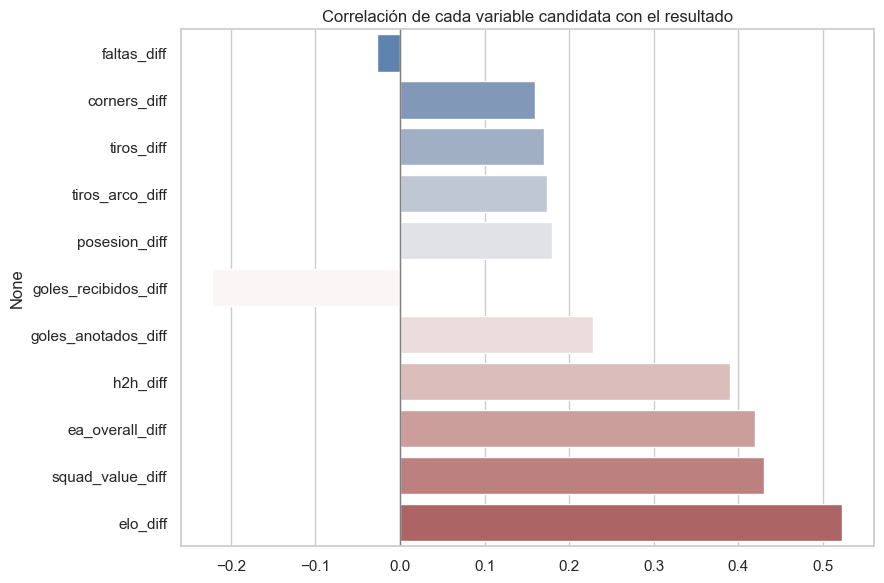

Mayor correlación: elo, valor de plantilla, EA y h2h. La forma (goles) aporta menos;
el estilo (tiros/posesión/córners) poco; las faltas, prácticamente nada.


In [27]:
cy = data[CAND].corrwith(data['resultado']).sort_values(key=abs)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=cy.values, y=cy.index, palette='vlag', ax=ax); ax.axvline(0, color='grey', lw=1)
ax.set_title('Correlación de cada variable candidata con el resultado'); plt.tight_layout(); plt.show()
print('Mayor correlación: elo, valor de plantilla, EA y h2h. La forma (goles) aporta menos;')
print('el estilo (tiros/posesión/córners) poco; las faltas, prácticamente nada.')

## 3 · Selección de variables (sin fuga)

Para evitar la colinealidad y la fuga de información, se realiza un proceso de selección de variables en tres etapas:
1. **Filtro de colinealidad (VIF):** Eliminación de variables altamente correlacionadas.
2. **Selección hacia adelante (Forward Selection):** Evaluación iterativa mediante validación cruzada temporal (`TimeSeriesSplit` en el conjunto de entrenamiento).
3. **Análisis de significancia:** Validación de coeficientes y p-values del modelo.

In [28]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

CORTE_TEST = '2025-01-01'
train = data[data.fecha < CORTE_TEST].reset_index(drop=True)   # la selección SOLO ve el train
y = train['resultado']
cv = TimeSeriesSplit(5)

def vifs(fs):
    X = sm.add_constant(train[fs])
    return {f: variance_inflation_factor(X.values, i + 1) for i, f in enumerate(fs)}

def ll(fs):
    p = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000))])
    return -cross_val_score(p, train[fs], y, cv=cv, scoring='neg_log_loss').mean()

# (A) VIF iterativo
feats = CAND[:]; print('(A) VIF iterativo (quito la peor hasta VIF<5):')
while True:
    v = vifs(feats); p = max(v, key=v.get)
    if v[p] < 5: break
    print(f'   quito {p} (VIF={v[p]:.1f})'); feats.remove(p)
if len(feats) == len(CAND):
    print(f'   ninguna eliminada — VIF máximo: {max(vifs(feats).values()):.1f} (las diffs no son colineales)')

# (B) forward por CV temporal
print('(B) Selección forward (log-loss, walk-forward CV):')
sel, rem, best = [], feats[:], 99
while rem:
    sc = {f: ll(sel + [f]) for f in rem}; bf = min(sc, key=sc.get)
    if sc[bf] < best - 0.001:
        sel.append(bf); rem.remove(bf); print(f'   + {bf:20} log-loss={sc[bf]:.4f}'); best = sc[bf]
    else:
        break
FINAL = sel
print(f'\n>>> SET FINAL (sin fuga): {FINAL}')
print(f'   log-loss con las 11 candidatas: {ll(CAND):.4f}  |  solo elo: {ll(["elo_diff"]):.4f}  |  set final: {ll(FINAL):.4f}')
print(f'   VIF del set final:', {k: round(v, 1) for k, v in vifs(FINAL).items()})

(A) VIF iterativo (quito la peor hasta VIF<5):
   ninguna eliminada — VIF máximo: 4.7 (las diffs no son colineales)
(B) Selección forward (log-loss, walk-forward CV):
   + elo_diff             log-loss=0.9115
   + h2h_diff             log-loss=0.9076
   + squad_value_diff     log-loss=0.9064

>>> SET FINAL (sin fuga): ['elo_diff', 'h2h_diff', 'squad_value_diff']
   log-loss con las 11 candidatas: 0.9160  |  solo elo: 0.9115  |  set final: 0.9064
   VIF del set final: {'elo_diff': 2.6, 'h2h_diff': 1.7, 'squad_value_diff': 2.1}


In [29]:
# RENDICIÓN DE CUENTAS: probamos agregar CADA candidata al set final
base = ll(FINAL)
Xv = sm.add_constant(train[CAND])
VIF = {f: variance_inflation_factor(Xv.values, i + 1) for i, f in enumerate(CAND)}
corr = train[CAND].corrwith(y); filas = []
for f in CAND:
    if f in FINAL:
        filas.append([f, round(corr[f], 2), round(VIF[f], 1), '—', '✅ seleccionada']); continue
    gain = base - ll(FINAL + [f])
    razon = 'VIF alto (colinealidad)' if VIF[f] > 5 else ('no mejora / mete ruido' if gain <= 0.001 else 'aporte mínimo')
    filas.append([f, round(corr[f], 2), round(VIF[f], 1), round(gain, 4), '❌ ' + razon])
display(style_table(pd.DataFrame(filas, columns=['variable', 'corr_target', 'VIF', 'mejora_log_loss', 'destino'])))

,variable,corr_target,VIF,mejora_log_loss,destino
0,elo_diff,0.510000,3.100000,—,✅ seleccionada
1,squad_value_diff,0.410000,4.400000,—,✅ seleccionada
2,ea_overall_diff,0.400000,4.700000,-0.000800,❌ no mejora / mete ruido
3,h2h_diff,0.380000,1.700000,—,✅ seleccionada
4,goles_anotados_diff,0.220000,1.200000,-0.000800,❌ no mejora / mete ruido
5,goles_recibidos_diff,-0.220000,1.200000,-0.000400,❌ no mejora / mete ruido
6,tiros_diff,0.140000,3.300000,-0.002800,❌ no mejora / mete ruido
7,tiros_arco_diff,0.150000,3.100000,-0.001800,❌ no mejora / mete ruido
8,corners_diff,0.140000,1.700000,-0.001200,❌ no mejora / mete ruido
9,posesion_diff,0.170000,1.400000,-0.004400,❌ no mejora / mete ruido


**Resultado de la selección:**
El proceso selecciona **3 variables** clave que minimizan el Log-Loss temporal:
1. `elo_diff` (Diferencia de rating Elo)
2. `h2h_diff` (Diferencia histórica de gol promedio en enfrentamientos directos)
3. `squad_value_diff` (Diferencia en el valor estimado de las plantillas)

El uso de estas 3 variables supera predictivamente tanto a un modelo basado únicamente en Elo como al modelo con las 11 variables candidatas (que introducen ruido).

### 3.1 · Ventana temporal para el Head-to-Head (H2H)

Evaluación del impacto de restringir el historial de enfrentamientos directos (`h2h_diff`) a la última década versus utilizar el historial completo desde 1872.

In [30]:
from collections import defaultdict

hist_h2h = pd.read_csv('results.csv', parse_dates=['date']).dropna(subset=['home_score', 'away_score'])
idx_duelos = defaultdict(list)
for r in hist_h2h.sort_values('date').itertuples(index=False):
    k = (r.home_team, r.away_team) if r.home_team < r.away_team else (r.away_team, r.home_team)
    d = r.home_score - r.away_score if r.home_team == k[0] else r.away_score - r.home_score
    idx_duelos[k].append((r.date, d))   # d = dif. de gol desde la perspectiva de k[0]

def h2h_ventanas(a, b, fecha):
    k = (a, b) if a < b else (b, a)
    sgn = 1 if a == k[0] else -1
    prev = [(t, d) for t, d in idx_duelos[k] if t < fecha]
    var = {'completo (desde 1872)': prev,
           'últimos 20 años': [(t, d) for t, d in prev if t >= fecha - pd.DateOffset(years=20)],
           'última década': [(t, d) for t, d in prev if t >= fecha - pd.DateOffset(years=10)],
           'últimos 5 duelos': prev[-5:],
           'últimos 10 duelos': prev[-10:]}
    return {n: (sgn * float(np.mean([d for _, d in v])) if v else 0.0, len(v)) for n, v in var.items()}

vals = [h2h_ventanas(r.local, r.visita, r.fecha) for r in train.itertuples(index=False)]

# Test de reproducibilidad: el recálculo 'completo' debe coincidir con la columna del dataset
full_rec = np.array([v['completo (desde 1872)'][0] for v in vals])
err_max = np.abs(train.h2h_diff.values - full_rec.round(3)).max()
print(f'Reproducibilidad del pipeline: |h2h recalculado - columna del dataset| máx = {err_max:.4f}\n')

def ll_con_h2h(col):
    Xv = train[['elo_diff', 'squad_value_diff']].copy()
    if col is not None:
        Xv['h2h'] = col
    p = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000))])
    return -cross_val_score(p, Xv, y, cv=cv, scoring='neg_log_loss').mean()

filas = [{'variante de h2h': 'sin h2h', 'cobertura': '—', 'duelos prom.': '—', 'LogLoss CV': ll_con_h2h(None)}]
for n in vals[0]:
    col = np.array([v[n][0] for v in vals]); cnt = np.array([v[n][1] for v in vals])
    filas.append({'variante de h2h': n, 'cobertura': f'{(cnt > 0).mean():.1%}',
                  'duelos prom.': round(cnt.mean(), 1), 'LogLoss CV': ll_con_h2h(col)})
tabla_h2h = pd.DataFrame(filas).set_index('variante de h2h')
display(tabla_h2h.round(4).style.highlight_min(subset=['LogLoss CV'], color='lightgreen').set_properties(**{'font-family': 'Inter, sans-serif', 'padding': '10px 14px', 'font-size': '13px'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e293b'), ('color', 'white'), ('padding', '10px 14px')]}]))

Reproducibilidad del pipeline: |h2h recalculado - columna del dataset| máx = 0.0000



,cobertura,duelos prom.,LogLoss CV
variante de h2h,,,
sin h2h,—,—,0.909800
completo (desde 1872),87.4%,13.800000,0.906400
últimos 20 años,83.8%,5.100000,0.907200
última década,73.8%,2.600000,0.907000
últimos 5 duelos,87.4%,3.700000,0.906600
últimos 10 duelos,87.4%,6.000000,0.906100


**Resultado:**
La restricción a una ventana corta (como 10 años) disminuye la cobertura de datos debido a la baja frecuencia de partidos entre muchas selecciones. Se decide mantener el cálculo histórico completo.

## 4 · División train/test y entrenamiento

Se utiliza una **división temporal** para la validación:
* **Entrenamiento (Train):** Partidos entre 2019 y 2024.
* **Prueba (Test):** Partidos desde enero de 2025 hasta junio de 2026 (~1,000 partidos).

In [31]:
test = data[data.fecha >= CORTE_TEST].reset_index(drop=True)
Xtr, ytr = train[FINAL], train['resultado']
Xte, yte = test[FINAL], test['resultado']
pipe = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=2000))]).fit(Xtr, ytr)
print(f"Train: {len(Xtr):,} ({train.fecha.min().date()} -> {train.fecha.max().date()})")
print(f"Test : {len(Xte):,} ({test.fecha.min().date()} -> {test.fecha.max().date()})")
print(f"Variables: {FINAL}")

Train: 3,978 (2019-01-02 -> 2024-12-22)
Test : 1,045 (2025-01-04 -> 2026-06-09)
Variables: ['elo_diff', 'h2h_diff', 'squad_value_diff']


## 5 · Significancia (pseudo-R², p-values, coeficientes)

In [32]:
mn = sm.MNLogit(ytr.values, sm.add_constant(StandardScaler().fit_transform(Xtr))).fit(disp=0)
print(f'Pseudo-R² (McFadden) = {mn.prsquared:.3f}\n')
Pp, Pv = np.asarray(mn.params), np.asarray(mn.pvalues); nombres = ['const'] + FINAL
for k, clase in [(0, 'EMPATE vs Derrota'), (1, 'VICTORIA vs Derrota')]:
    t = pd.DataFrame({'variable': nombres, 'coef': Pp[:, k], 'p_value': Pv[:, k]})
    t['signif'] = np.where(t.p_value < 0.05, '✓', '')
    print(f'--- {clase} ---'); print(t.round(3).to_string(index=False)); print()

Pseudo-R² (McFadden) = 0.149

--- EMPATE vs Derrota ---
        variable  coef  p_value signif
           const 0.387    0.000      ✓
        elo_diff 0.756    0.000      ✓
        h2h_diff 0.176    0.008      ✓
squad_value_diff 0.093    0.164       

--- VICTORIA vs Derrota ---
        variable  coef  p_value signif
           const 0.653      0.0      ✓
        elo_diff 1.332      0.0      ✓
        h2h_diff 0.381      0.0      ✓
squad_value_diff 0.266      0.0      ✓



**Análisis de coeficientes:**
Las tres variables resultan estadísticamente significativas ($p < 0.05$) para la clase de Victoria, mostrando signos coherentes (mayor Elo, mejor H2H y mayor valor de plantilla aumentan la probabilidad de victoria).

## 6 · Matriz de confusión (test temporal 2025–26)

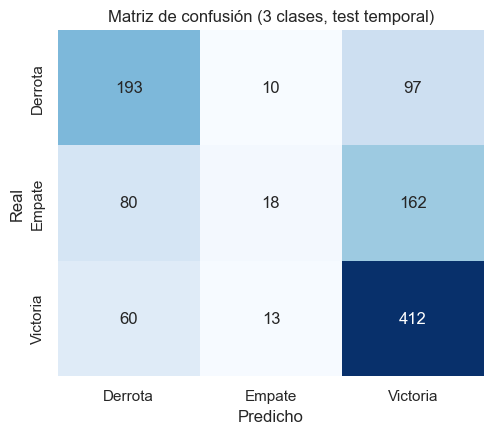

              precision    recall  f1-score   support

     Derrota       0.58      0.64      0.61       300
      Empate       0.44      0.07      0.12       260
    Victoria       0.61      0.85      0.71       485

    accuracy                           0.60      1045
   macro avg       0.54      0.52      0.48      1045
weighted avg       0.56      0.60      0.54      1045

Accuracy=0.596 | LogLoss=0.852


In [33]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, log_loss

pred = pipe.predict(Xte); proba = pipe.predict_proba(Xte)
cm = confusion_matrix(yte, pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Derrota', 'Empate', 'Victoria'], yticklabels=['Derrota', 'Empate', 'Victoria'])
ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title('Matriz de confusión (3 clases, test temporal)')
plt.show()
print(classification_report(yte, pred, labels=[0, 1, 2], target_names=['Derrota', 'Empate', 'Victoria']))
print(f'Accuracy={accuracy_score(yte, pred):.3f} | LogLoss={log_loss(yte, proba):.3f}')

**Análisis de predicciones:**
La matriz de confusión muestra que el modelo clasifica correctamente victorias y derrotas, pero casi nunca predice empates mediante la clase mayoritaria (*argmax*). Esto es debido a la naturaleza probabilística del empate en fútbol.

## 6b · Tratamiento del empate

En la simulación del torneo no se utiliza el resultado directo por *argmax*, sino la distribución de probabilidades completa. El rendimiento probabilístico del modelo se evalúa mediante Log-Loss y Ranked Probability Score (RPS).

In [34]:
def rps(P, yv):
    Pc = np.cumsum(P, 1); Oc = np.cumsum(np.eye(3)[np.asarray(yv)], 1)
    return np.mean(np.sum((Pc - Oc) ** 2, 1)) / (3 - 1)

print(f'1) Calibración: P(empate) media={proba[:, 1].mean():.3f} vs tasa real={(yte == 1).mean():.3f}')
print(f'2) RPS (métrica profesional V/E/D) = {rps(proba, yte.values):.3f}  (menor=mejor)')
for w in [None, 'balanced']:
    mm = Pipeline([('sc', StandardScaler()),
                   ('m', LogisticRegression(max_iter=2000, class_weight=w))]).fit(Xtr, ytr)
    print(f'3) class_weight={str(w):9}: {(mm.predict(Xte) == 1).sum():3d} empates predichos | '
          f'LogLoss={log_loss(yte, mm.predict_proba(Xte)):.3f}')
print('   -> forzar empates (balanced) empeora el log-loss. El modelo ya da bien la PROBABILIDAD del empate.')

1) Calibración: P(empate) media=0.273 vs tasa real=0.249
2) RPS (métrica profesional V/E/D) = 0.162  (menor=mejor)
3) class_weight=None     :  41 empates predichos | LogLoss=0.852
3) class_weight=balanced : 273 empates predichos | LogLoss=0.880
   -> forzar empates (balanced) empeora el log-loss. El modelo ya da bien la PROBABILIDAD del empate.


## 7 · ROC y calibración (clase Victoria)

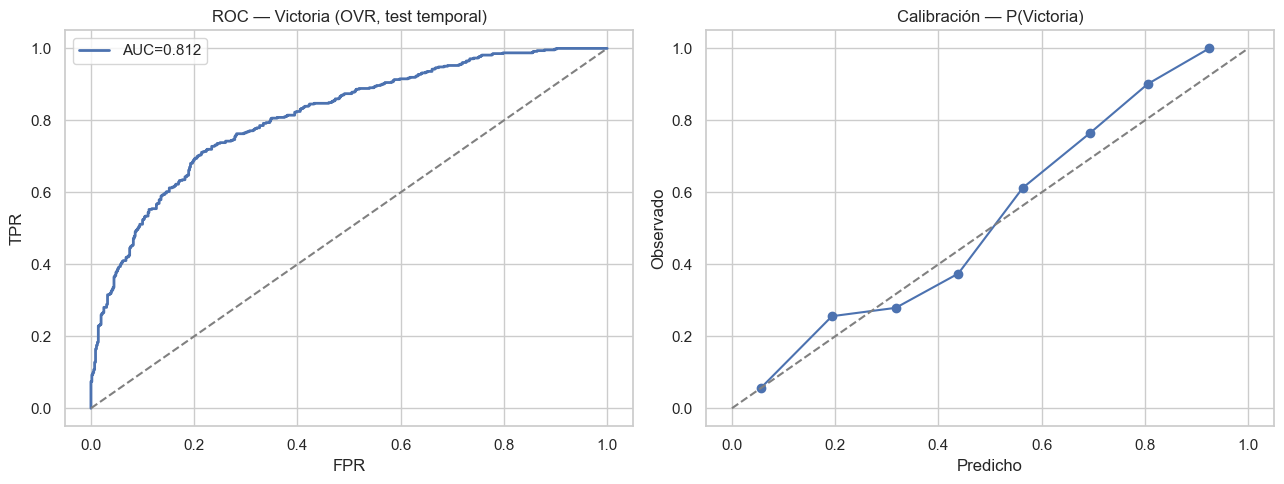

AUC (OVR macro) = 0.761


In [35]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.calibration import calibration_curve

yv = (yte == 2).astype(int); pv = proba[:, 2]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(yv, pv)
ax[0].plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr, tpr):.3f}'); ax[0].plot([0, 1], [0, 1], '--', color='grey')
ax[0].set_title('ROC — Victoria (OVR, test temporal)'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
po, pp_ = calibration_curve(yv, pv, n_bins=8)
ax[1].plot(pp_, po, 'o-'); ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_title('Calibración — P(Victoria)'); ax[1].set_xlabel('Predicho'); ax[1].set_ylabel('Observado')
plt.tight_layout(); plt.show()
print(f"AUC (OVR macro) = {roc_auc_score(yte, proba, multi_class='ovr', average='macro'):.3f}")

## 8 · Modelos alternativos (CV temporal, 5 cortes)

Comparación del set de variables seleccionado frente a múltiples familias de modelos e hiperparámetros mediante validación cruzada temporal:
* **Modelos basados en el set de 3 variables:** Regresión Logística, Máquinas de Soporte Vectorial (SVM), Red Neuronal (MLP), y Regresión Logística Ordinal (enlaces logit y probit).
* **Modelos de selección automática (con las 11 variables):** Regularización Lasso (L1), Ridge (L2), Elastic Net, Random Forest, HistGradientBoosting, y XGBoost.

In [36]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

def _logit(**kw):
    return LogisticRegression(max_iter=4000, **kw)

# Hiperparámetros por el mismo walk-forward (nada por defecto)
def cv_ll(model, fs):
    return -cross_val_score(model, train[fs], ytr, cv=cv, scoring='neg_log_loss').mean()

def mejor_C(penalty, solver='lbfgs'):
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=penalty, solver=solver, C=Cv))]), CAND)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0]}
    Cb = min(sc, key=sc.get)
    print(f'   {penalty.upper():4} sobre las 11 -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_elastic():
    sc = {(Cv, r): cv_ll(Pipeline([('sc', StandardScaler()),
                                   ('m', _logit(penalty='elasticnet', solver='saga', C=Cv, l1_ratio=r))]), CAND)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0] for r in [0.25, 0.5, 0.75]}
    (Cb, rb) = min(sc, key=sc.get)
    print(f'   ELASTIC NET sobre las 11 -> mejor C={Cb}, l1_ratio={rb} (log-loss {sc[(Cb, rb)]:.4f})')
    return Cb, rb

def mejor_C_svm():
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()),
                              ('m', SVC(kernel='rbf', C=Cv, probability=True, random_state=SEED))]), FINAL)
          for Cv in [0.3, 1, 3, 10]}
    Cb = min(sc, key=sc.get)
    print(f'   SVM RBF sobre el set final -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_xgb():
    sc = {}
    for d in [2, 3]:
        for n in [100, 300]:
            m = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, objective='multi:softprob', eval_metric='mlogloss',
                              random_state=SEED, n_jobs=-1, verbosity=0)
            sc[(d, n)] = cv_ll(m, CAND)
    (db, nb) = min(sc, key=sc.get)
    print(f'   XGBOOST sobre las 11 -> mejor depth={db}, n_estimators={nb} (log-loss {sc[(db, nb)]:.4f})')
    return db, nb

def mejor_mlp():
    sc = {}
    for h in [(8,), (16, 8)]:
        for a in [1e-3, 1e-2]:
            m = Pipeline([('sc', StandardScaler()),
                          ('m', MLPClassifier(hidden_layer_sizes=h, alpha=a, max_iter=2000,
                                              early_stopping=True, n_iter_no_change=20, random_state=SEED))])
            sc[(h, a)] = cv_ll(m, FINAL)
    (hb, ab) = min(sc, key=sc.get)
    print(f'   MLP sobre el set final -> mejor hidden={hb}, alpha={ab} (log-loss {sc[(hb, ab)]:.4f})')
    return hb, ab

print('Eligiendo hiperparámetros por CV temporal:')
C_l1 = mejor_C('l1', solver='saga')
C_l2 = mejor_C('l2')
C_en, r_en = mejor_elastic()
C_svm = mejor_C_svm()
d_xgb, n_xgb = mejor_xgb()
h_mlp, a_mlp = mejor_mlp()

mods = {
    'Logística (set final, forward)': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), FINAL),
    'Interacciones (set final)': (Pipeline([('sc', StandardScaler()),
                                            ('p', PolynomialFeatures(2, interaction_only=True, include_bias=False)),
                                            ('m', _logit())]), FINAL),
    f'SVM RBF (set final, C={C_svm})': (Pipeline([('sc', StandardScaler()),
                                                  ('m', SVC(kernel='rbf', C=C_svm, probability=True, random_state=SEED))]), FINAL),
    f'Lasso (las 11, C={C_l1})': (Pipeline([('sc', StandardScaler()),
                                            ('m', _logit(penalty='l1', solver='saga', C=C_l1))]), CAND),
    f'Ridge (las 11, C={C_l2})': (Pipeline([('sc', StandardScaler()),
                                            ('m', _logit(penalty='l2', C=C_l2))]), CAND),
    f'Elastic Net (las 11, C={C_en}, r={r_en})': (Pipeline([('sc', StandardScaler()),
                                                            ('m', _logit(penalty='elasticnet', solver='saga',
                                                                         C=C_en, l1_ratio=r_en))]), CAND),
    f'MLP {h_mlp} (set final)': (Pipeline([('sc', StandardScaler()),
                                           ('m', MLPClassifier(hidden_layer_sizes=h_mlp, alpha=a_mlp, max_iter=2000,
                                                               early_stopping=True, n_iter_no_change=20,
                                                               random_state=SEED))]), FINAL),
    'Random Forest (las 11)': (RandomForestClassifier(n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1), CAND),
    'Grad. Boosting (las 11, early stop)': (HistGradientBoostingClassifier(
        learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=40, max_iter=1000,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=25, random_state=SEED), CAND),
    f'XGBoost (las 11, depth={d_xgb}, n={n_xgb})': (XGBClassifier(
        n_estimators=n_xgb, max_depth=d_xgb, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0), CAND),
    'Ref: solo Elo': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), ['elo_diff']),
    'Ref: las 11 sin regularizar': (Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=None))]), CAND),
}

rps_scorer = make_scorer(lambda yv_, P: rps(P, yv_), response_method='predict_proba', greater_is_better=False)
res = []
for nom, (mod, fs) in mods.items():
    s = cross_validate(mod, train[fs], ytr, cv=cv, scoring={'acc': 'accuracy', 'll': 'neg_log_loss', 'rps': rps_scorer})
    res.append({'Modelo': nom, 'Accuracy': s['test_acc'].mean(),
                'LogLoss': -s['test_ll'].mean(), 'RPS': -s['test_rps'].mean()})

# ORDINAL en sus dos enlaces, logit y PROBIT (¿importa la función de enlace? — comprobémoslo
# en vez de asumirlo). statsmodels no es compatible con cross_validate -> mismo CV, loop manual.
from statsmodels.miscmodels.ordinal_model import OrderedModel
for distr, nombre_d in [('logit', 'Ordinal logit (set final)'), ('probit', 'Ordinal probit (set final)')]:
    lls, accs, rpss = [], [], []
    for tr_, va_ in cv.split(train):
        sc_ = StandardScaler().fit(train[FINAL].iloc[tr_])
        res_o = OrderedModel(ytr.values[tr_], sc_.transform(train[FINAL].iloc[tr_]), distr=distr).fit(method='bfgs', disp=0)
        P_o = np.asarray(res_o.predict(sc_.transform(train[FINAL].iloc[va_])))
        yva = ytr.values[va_]
        lls.append(log_loss(yva, P_o, labels=[0, 1, 2])); accs.append((P_o.argmax(1) == yva).mean()); rpss.append(rps(P_o, yva))
    res.append({'Modelo': nombre_d, 'Accuracy': np.mean(accs), 'LogLoss': np.mean(lls), 'RPS': np.mean(rpss)})

tabla = pd.DataFrame(res).set_index('Modelo').sort_values('LogLoss')
display(tabla.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen').set_properties(**{'font-family': 'Inter, sans-serif', 'padding': '10px 14px', 'font-size': '13px'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e293b'), ('color', 'white'), ('padding', '10px 14px')]}]))
best = next(n for n in tabla.index if n in mods)   # mejor modelo con API sklearn
MODEL_BEST, FEATS_BEST = mods[best]
print(f'>>> Mejor por CV temporal: {best} (variables: {FEATS_BEST})')
ev_test = MODEL_BEST.fit(train[FEATS_BEST], ytr)
P_best = ev_test.predict_proba(test[FEATS_BEST])
print(f'    En test 2025-26: LogLoss={log_loss(yte, P_best):.4f} | RPS={rps(P_best, yte.values):.4f} | '
      f'Accuracy={accuracy_score(yte, P_best.argmax(1)):.4f}')

Eligiendo hiperparámetros por CV temporal:
   L1   sobre las 11 -> mejor C=0.1 (log-loss 0.9129)
   L2   sobre las 11 -> mejor C=0.1 (log-loss 0.9158)
   ELASTIC NET sobre las 11 -> mejor C=0.1, l1_ratio=0.75 (log-loss 0.9133)
   SVM RBF sobre el set final -> mejor C=0.3 (log-loss 0.9441)
   XGBOOST sobre las 11 -> mejor depth=2, n_estimators=100 (log-loss 0.9254)
   MLP sobre el set final -> mejor hidden=(8,), alpha=0.01 (log-loss 0.9379)


,Accuracy,LogLoss,RPS
Modelo,,,
"Logística (set final, forward)",0.562600,0.906400,0.173400
Ordinal probit (set final),0.558100,0.906500,0.173600
Ordinal logit (set final),0.559900,0.907200,0.173600
Interacciones (set final),0.564100,0.908900,0.173800
Ref: solo Elo,0.563500,0.911500,0.174900
"Lasso (las 11, C=0.1)",0.561700,0.912900,0.174800
"Elastic Net (las 11, C=0.1, r=0.75)",0.559600,0.913300,0.174900
"Ridge (las 11, C=0.1)",0.556000,0.915800,0.175400
Ref: las 11 sin regularizar,0.556000,0.916100,0.175400


>>> Mejor por CV temporal: Logística (set final, forward) (variables: ['elo_diff', 'h2h_diff', 'squad_value_diff'])
    En test 2025-26: LogLoss=0.8517 | RPS=0.1616 | Accuracy=0.5962


In [37]:
# CAMINO DE REGULARIZACIÓN DEL LASSO: qué variables sobreviven a cada nivel de penalización.
# (C pequeño = penalización dura; C grande = suave). Nada de C "a ojo": el óptimo PREDICTIVO
# es el C elegido por CV arriba; el camino completo muestra el ORDEN en que caen las variables.
print('Camino de selección del Lasso sobre las 11 candidatas:')
for Cf in [0.002, 0.003, 0.005, 0.01, 0.03, 0.1, 0.3, 1.0]:
    m = Pipeline([('sc', StandardScaler()),
                  ('m', _logit(penalty='l1', solver='saga', C=Cf))]).fit(train[CAND], ytr)
    coefs = m.named_steps['m'].coef_
    vivas = [f for k, f in enumerate(CAND) if np.abs(coefs[:, k]).max() > 1e-8]
    caen = sorted(set(CAND) - set(vivas))
    detalle = ', '.join(vivas) if len(vivas) <= 4 else (
        'las 11' if not caen else f"todas menos: {', '.join(caen)}")
    marca = '   <<< C óptimo por CV (tabla)' if Cf == C_l1 else ''
    print(f'  C={Cf:<6} -> {len(vivas):2d} vivas: {detalle}{marca}')
print(f'\nForward (sección 3) había elegido: {FINAL}')

Camino de selección del Lasso sobre las 11 candidatas:
  C=0.002  ->  1 vivas: elo_diff
  C=0.003  ->  2 vivas: elo_diff, squad_value_diff
  C=0.005  ->  3 vivas: elo_diff, squad_value_diff, h2h_diff
  C=0.01   ->  3 vivas: elo_diff, squad_value_diff, h2h_diff
  C=0.03   ->  8 vivas: todas menos: ea_overall_diff, tiros_arco_diff, tiros_diff
  C=0.1    -> 10 vivas: todas menos: ea_overall_diff   <<< C óptimo por CV (tabla)
  C=0.3    -> 11 vivas: las 11
  C=1.0    -> 11 vivas: las 11

Forward (sección 3) había elegido: ['elo_diff', 'h2h_diff', 'squad_value_diff']


**Conclusiones de la comparación de modelos:**
1. **Convergencia:** La regularización Lasso (L1) confirma que las últimas variables en ser penalizadas a cero coinciden exactamente con el set seleccionado de 3 variables.
2. **Linealidad:** Los modelos lineales superan a los algoritmos basados en árboles (Random Forest, Gradient Boosting, XGBoost) y redes neuronales, los cuales tienden al sobreajuste debido a la relación monótona entre las variables y el resultado.
3. **Métricas:** Modelos como SVM optimizan la frontera de decisión (Accuracy) pero ofrecen peor calibración probabilística (Log-Loss).

## 9 · Simulación del Mundial 2026 (Monte Carlo)

Simulación del torneo de 48 equipos mediante 10,000 iteraciones utilizando las predicciones probabilísticas del modelo re-entrenado con todos los datos disponibles.

**Mejoras incorporadas:**
1. **Simetrización de localía:** Predicciones promediadas en ambas orientaciones para partidos neutrales. Los anfitriones (USA, México, Canadá) conservan la localía en sus partidos.
2. **Generación de marcadores verosímiles:** Distribución de goles Poisson condicionada a la probabilidad de resultado (V/E/D) para resolver desempates en fase de grupos.
3. **Ranking de terceros:** Simulación del bracket de eliminación directa utilizando el reglamento oficial de clasificación de los mejores terceros.

In [38]:
from sklearn.base import clone
from scipy.stats import poisson
from itertools import permutations

# Modelo definitivo: mejor configuración, entrenada con TODO (2019 -> jun-2026)
final_model = clone(MODEL_BEST).fit(data[FEATS_BEST], data['resultado'])

states = pd.read_csv('team_states.csv').set_index('team')
hist = pd.read_csv('results.csv', parse_dates=['date']).dropna(subset=['home_score', 'away_score'])

# Letras verificadas contra el calendario oficial del fixture (results.csv): México abre el
# Mundial en el Azteca el 11-jun (Grupo A), Canadá el 12-jun (B) y USA el 12-jun (D) — regla FIFA
# de anfitriones — y el resto por orden de primera aparición en el calendario (C 13-jun, E/F 14,
# G/H 15, I/J 16, K/L 17), consistente con el sorteo oficial de diciembre 2025.
GRUPOS = {
    'A': ['Czech Republic', 'Mexico', 'South Africa', 'South Korea'],
    'B': ['Bosnia and Herzegovina', 'Canada', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Haiti', 'Morocco', 'Scotland'],
    'D': ['Australia', 'Paraguay', 'Turkey', 'United States'],
    'E': ['Curaçao', 'Ecuador', 'Germany', 'Ivory Coast'],
    'F': ['Japan', 'Netherlands', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay'],
    'I': ['France', 'Iraq', 'Norway', 'Senegal'],
    'J': ['Algeria', 'Argentina', 'Austria', 'Jordan'],
    'K': ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
    'L': ['Croatia', 'England', 'Ghana', 'Panama'],
}
MUNDIALISTAS = [t for eqs in GRUPOS.values() for t in eqs]
ANFITRIONES = {'United States', 'Canada', 'Mexico'}

# Head-to-head histórico entre los 48 (idéntica semántica que el entrenamiento)
m48 = set(MUNDIALISTAS)
duelos = hist[hist.home_team.isin(m48) & hist.away_team.isin(m48)]
H2H = {}
for r in duelos.itertuples(index=False):
    d = r.home_score - r.away_score
    for a, b, s in ((r.home_team, r.away_team, d), (r.away_team, r.home_team, -d)):
        H2H.setdefault((a, b), []).append(s)
H2H = {k: float(np.mean(v)) for k, v in H2H.items()}


def features_cruce(a, b):
    '''Las 11 candidatas del cruce con `a` como local administrativo.'''
    sa, sb = states.loc[a], states.loc[b]
    return pd.DataFrame([{
        'elo_diff': sa.elo - sb.elo,
        'squad_value_diff': np.log(sa.squad_value) - np.log(sb.squad_value),
        'ea_overall_diff': sa.ea_overall - sb.ea_overall,
        'h2h_diff': H2H.get((a, b), 0.0),
        'goles_anotados_diff': sa.goles_anotados_avg - sb.goles_anotados_avg,
        'goles_recibidos_diff': sa.goles_recibidos_avg - sb.goles_recibidos_avg,
        'tiros_diff': sa.tiros_avg - sb.tiros_avg,
        'tiros_arco_diff': sa.tiros_arco_avg - sb.tiros_arco_avg,
        'corners_diff': sa.corners_avg - sb.corners_avg,
        'posesion_diff': sa.posesion_avg - sb.posesion_avg,
        'faltas_diff': sa.faltas_avg - sb.faltas_avg,
    }])


def prob_partido(a, b):
    '''[P(gana a), P(empate), P(gana b)] con simetrización; anfitriones conservan localía.'''
    pa = final_model.predict_proba(features_cruce(a, b)[FEATS_BEST])[0]   # clases [0=gana b, 1=emp, 2=gana a]
    pb = final_model.predict_proba(features_cruce(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])
    vb = np.array([pb[0], pb[1], pb[2]])
    if a in ANFITRIONES and b not in ANFITRIONES: return va
    if b in ANFITRIONES and a not in ANFITRIONES: return vb
    return (va + vb) / 2


# Poisson auxiliar (Elo -> goles esperados) SOLO para rellenar marcadores condicionados
espn = pd.read_csv('espn_stats.csv', parse_dates=['fecha'])
espn = espn[(espn.fecha >= '2019-01-01') & espn.goles_local.notna()]
largo = pd.concat([
    pd.DataFrame({'g': espn.goles_local.values, 'd': (espn.elo_local - espn.elo_visita).values}),
    pd.DataFrame({'g': espn.goles_visita.values, 'd': (espn.elo_visita - espn.elo_local).values})])
gp = sm.GLM(largo['g'], sm.add_constant(largo[['d']]), family=sm.families.Poisson()).fit()
gb0, gb1 = gp.params['const'], gp.params['d']

def lambdas_elo(a, b):
    d = states.loc[a, 'elo'] - states.loc[b, 'elo']
    return float(np.exp(gb0 + gb1 * d)), float(np.exp(gb0 - gb1 * d))

p = prob_partido('Spain', 'Argentina')
print(f'Ejemplo — España vs Argentina (neutral): {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')
p = prob_partido('United States', 'Paraguay')
print(f'Ejemplo — USA (anfitrión) vs Paraguay  : {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')

Ejemplo — España vs Argentina (neutral): 37.2% / 33.6% / 29.2%
Ejemplo — USA (anfitrión) vs Paraguay  : 36.8% / 32.8% / 30.4%


### 9.1 · Partido a partido: los 72 partidos de la fase de grupos

Probabilidades calculadas para cada encuentro de la fase de grupos. Los resultados detallados se guardan en `predicciones_fase_grupos.csv`.

In [39]:
filas = []
for g, eqs in GRUPOS.items():
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = eqs[i], eqs[j]
            if b in ANFITRIONES and a not in ANFITRIONES:
                a, b = b, a
            p = prob_partido(a, b); la, lb = lambdas_elo(a, b)
            filas.append({'grupo': g, 'equipo_1': a, 'equipo_2': b,
                          'cancha': 'anfitrión' if (a in ANFITRIONES) ^ (b in ANFITRIONES) else 'neutral',
                          'P(gana 1)': round(p[0], 3), 'P(empate)': round(p[1], 3), 'P(gana 2)': round(p[2], 3),
                          'goles_esp_1': round(la, 2), 'goles_esp_2': round(lb, 2)})
pred_grupos = pd.DataFrame(filas)
pred_grupos.to_csv('predicciones_fase_grupos.csv', index=False)
print('Guardado: predicciones_fase_grupos.csv (72 partidos)')
pred_grupos.head(12)

Guardado: predicciones_fase_grupos.csv (72 partidos)


,grupo,equipo_1,equipo_2,cancha,P(gana 1),P(empate),P(gana 2),goles_esp_1,goles_esp_2
0,A,Mexico,Czech Republic,anfitrión,0.488,0.335,0.177,1.57,0.78
1,A,Czech Republic,South Africa,neutral,0.507,0.311,0.183,1.46,0.84
2,A,Czech Republic,South Korea,neutral,0.324,0.338,0.338,0.96,1.28
3,A,Mexico,South Africa,anfitrión,0.727,0.218,0.055,2.06,0.59
4,A,Mexico,South Korea,anfitrión,0.514,0.315,0.171,1.36,0.90
5,A,South Africa,South Korea,neutral,0.144,0.291,0.566,0.73,1.69
6,B,Canada,Bosnia and Herzegovina,anfitrión,0.616,0.281,0.103,1.80,0.68
7,B,Bosnia and Herzegovina,Qatar,neutral,0.395,0.334,0.271,1.31,0.94
8,B,Bosnia and Herzegovina,Switzerland,neutral,0.159,0.298,0.543,0.62,1.97
9,B,Canada,Qatar,anfitrión,0.761,0.195,0.043,2.12,0.58


### 9.2 · Monte Carlo (10,000 mundiales, bracket oficial FIFA de 48)

In [40]:
rng = np.random.default_rng(SEED)
GRID_MAX = 10

# Bracket oficial: '1X'/'2X' = 1°/2° del grupo X; ('3', [...]) = mejor tercero permitido en esa llave.
R32 = {
    73: ('2A', '2B'), 74: ('1E', ('3', list('ABCDF'))), 75: ('1F', '2C'), 76: ('1C', '2F'),
    77: ('1I', ('3', list('CDFGH'))), 78: ('2E', '2I'), 79: ('1A', ('3', list('CEFHI'))),
    80: ('1L', ('3', list('EHIJK'))), 81: ('1D', ('3', list('BEFIJ'))), 82: ('1G', ('3', list('AEHIJ'))),
    83: ('2K', '2L'), 84: ('1H', '2J'), 85: ('1B', ('3', list('EFGIJ'))), 86: ('1J', '2H'),
    87: ('1K', ('3', list('DEIJL'))), 88: ('2D', '2G'),
}
R16 = {89: (74, 77), 90: (73, 75), 91: (76, 78), 92: (79, 80),
       93: (83, 84), 94: (81, 82), 95: (86, 88), 96: (85, 87)}
QF = {97: (89, 90), 98: (93, 94), 99: (91, 92), 100: (95, 96)}
SF = {101: (97, 98), 102: (99, 100)}
FINAL_M = (101, 102)


def asignar_terceros(grupos_terceros):
    '''Asigna los 8 terceros a los slots permitidos del bracket (matching bipartito máximo,
       algoritmo de Kuhn). Implementación determinista: mismo input -> misma asignación siempre.'''
    slots = {p: sorted(set(R32[p][1][1]) & grupos_terceros) for p in R32 if isinstance(R32[p][1], tuple)}
    asign, dueno = {}, {}   # slot -> grupo, grupo -> slot

    def intenta(p, visitados):
        for g in slots[p]:
            if g in visitados:
                continue
            visitados.add(g)
            if g not in dueno or intenta(dueno[g], visitados):
                dueno[g] = p; asign[p] = g
                return True
        return False

    for p in sorted(slots):
        intenta(p, set())
    for p in sorted(slots):                      # robustez: no debería ocurrir con las llaves FIFA
        if p not in asign:
            libres = sorted(set(grupos_terceros) - set(asign.values()))
            asign[p] = libres[0]
    return asign


# Precálculo: probabilidades y grillas de marcador condicionadas de los 2,256 cruces posibles
PROBS, SCORE_DIST = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    if (b, a) in PROBS:
        PROBS[(a, b)] = PROBS[(b, a)][::-1]
    else:
        PROBS[(a, b)] = prob_partido(a, b)
    la, lb = lambdas_elo(a, b)
    grid = np.outer(poisson.pmf(np.arange(GRID_MAX + 1), la), poisson.pmf(np.arange(GRID_MAX + 1), lb))
    grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    SCORE_DIST[(a, b)] = [np.cumsum((grid * mk).ravel() / (grid * mk).sum())
                          for mk in (gi > gj, gi == gj, gi < gj)]
print(f'Matriz de {len(PROBS):,} cruces lista. P(empate) media = {np.mean([v[1] for v in PROBS.values()]):.2f}')


def simular_partido(a, b, eliminatoria=False):
    p = PROBS[(a, b)]
    u = rng.random()
    res = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)   # 0=gana a, 1=empate, 2=gana b
    ga, gb = divmod(int(np.searchsorted(SCORE_DIST[(a, b)][res], rng.random())), GRID_MAX + 1)
    if res == 0: return ga, gb, a
    if res == 2: return ga, gb, b
    if eliminatoria:   # prórroga + penales en proporción a las prob. de victoria
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


def jugar_grupo(equipos, partido=simular_partido):
    pts = dict.fromkeys(equipos, 0); gf = dict.fromkeys(equipos, 0); gc = dict.fromkeys(equipos, 0)
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = partido(a, b)
            gf[a] += ga; gc[a] += gb; gf[b] += gb; gc[b] += ga
            if gan == a: pts[a] += 3
            elif gan == b: pts[b] += 3
            else: pts[a] += 1; pts[b] += 1
    return sorted(((t, pts[t], gf[t] - gc[t], gf[t], rng.random()) for t in equipos),
                  key=lambda x: (x[1], x[2], x[3], x[4]), reverse=True)


def jugar_mundial(partido=simular_partido):
    primeros, segundos, terceros = {}, {}, []
    for g, eqs in GRUPOS.items():
        tabla = jugar_grupo(eqs, partido)
        primeros[g], segundos[g] = tabla[0][0], tabla[1][0]
        t = tabla[2]
        terceros.append({'grupo': g, 'equipo': t[0], 'pts': t[1], 'gd': t[2], 'gf': t[3], 'rnd': t[4]})
    terceros.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
    tercero_por_grupo = {d['grupo']: d['equipo'] for d in terceros[:8]}
    asign = asignar_terceros(set(tercero_por_grupo))

    def slot(s, n):
        if isinstance(s, tuple): return tercero_por_grupo[asign[n]]
        return primeros[s[1]] if s[0] == '1' else segundos[s[1]]

    W = {}
    for n, (sa, sb) in R32.items():
        _, _, gan = partido(slot(sa, n), slot(sb, n), eliminatoria=True)
        W[n] = gan
    for ronda in (R16, QF, SF):
        for n, (p1, p2) in ronda.items():
            _, _, gan = partido(W[p1], W[p2], eliminatoria=True)
            W[n] = gan
    finalistas = (W[FINAL_M[0]], W[FINAL_M[1]])
    _, _, campeon = partido(*finalistas, eliminatoria=True)
    return {'campeon': campeon, 'finalistas': finalistas,
            'semifinalistas': [W[p] for p in (97, 98, 99, 100)],
            'a_octavos': [W[n] for n in R32]}


N_SIMS = 10000
cont = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial()
    cont[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont[t]['semi'] += 1
    for t in set(r['a_octavos']): cont[t]['octavos'] += 1

grupo_de = {t: g for g, eqs in GRUPOS.items() for t in eqs}
res_mc = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t], 'elo': round(states.loc[t, 'elo']),
                        'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                        'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                       for t, c in cont.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_mc.to_csv('probabilidades_torneo.csv', index=False)
print(f'{N_SIMS:,} Mundiales simulados. Guardado: probabilidades_torneo.csv')
display(style_table(res_mc.head(12)))

Matriz de 2,256 cruces lista. P(empate) media = 0.29
10,000 Mundiales simulados. Guardado: probabilidades_torneo.csv


,Selección,grupo,elo,P_campeon,P_final,P_semi,P_octavos
0,🇪🇸 Spain,H,2223,28.4%,41.7%,55.0%,81.5%
1,🇦🇷 Argentina,J,2189,19.5%,31.8%,46.6%,72.1%
2,🇫🇷 France,I,2128,11.7%,21.1%,39.2%,77.7%
3,🏴󠁧󠁢󠁥󠁮󠁧󠁿 England,L,2090,8.9%,17.5%,31.0%,73.6%
4,🇧🇷 Brazil,C,2069,7.3%,14.8%,28.3%,70.0%
5,🇵🇹 Portugal,K,2056,4.2%,9.8%,19.2%,64.3%
6,🇩🇪 Germany,E,2000,3.0%,7.2%,17.5%,63.7%
7,🇨🇴 Colombia,K,2064,2.8%,7.0%,15.0%,57.9%
8,🇳🇱 Netherlands,F,2004,2.4%,5.8%,15.7%,51.7%
9,🇲🇽 Mexico,A,1985,1.7%,5.0%,14.3%,64.7%


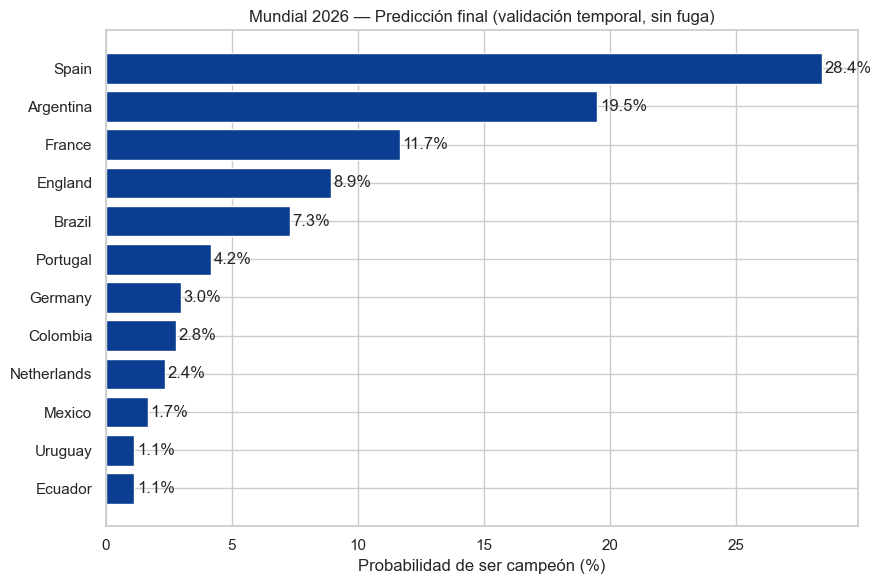

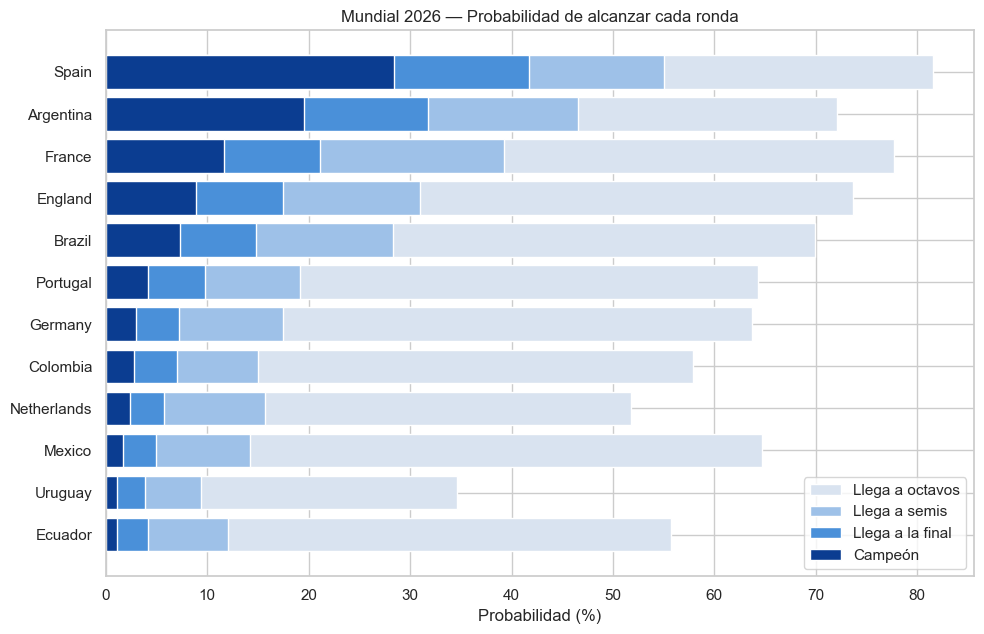

In [41]:
top = res_mc.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['Selección'], top.P_campeon * 100, color='#0b3d91')
for k, v in enumerate(top.P_campeon * 100):
    ax.text(v + 0.1, k, f'{v:.1f}%', va='center')
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 — Predicción final (validación temporal, sin fuga)')
plt.tight_layout(); plt.show()

t = res_mc.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(t['Selección'], t.P_octavos * 100, color='#d9e3f0', label='Llega a octavos')
ax.barh(t['Selección'], t.P_semi * 100, color='#9ec1e8', label='Llega a semis')
ax.barh(t['Selección'], t.P_final * 100, color='#4a90d9', label='Llega a la final')
ax.barh(t['Selección'], t.P_campeon * 100, color='#0b3d91', label='Campeón')
ax.set_xlabel('Probabilidad (%)'); ax.set_title('Mundial 2026 — Probabilidad de alcanzar cada ronda')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

### 9.3 · Simulación de un torneo de ejemplo

Visualización del desarrollo completo de una simulación individual (fase de grupos y fase de eliminación directa) fijando una semilla aleatoria.

In [42]:
rng = np.random.default_rng(2026)   # una realización concreta y reproducible

def jugar_grupo_detallado(equipos):
    st = {t: {'Pts': 0, 'PJ': 0, 'GF': 0, 'GC': 0} for t in equipos}
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = simular_partido(a, b)
            st[a]['PJ'] += 1; st[b]['PJ'] += 1
            st[a]['GF'] += ga; st[a]['GC'] += gb
            st[b]['GF'] += gb; st[b]['GC'] += ga
            if gan == a: st[a]['Pts'] += 3
            elif gan == b: st[b]['Pts'] += 3
            else: st[a]['Pts'] += 1; st[b]['Pts'] += 1
    orden = sorted(equipos, key=lambda t: (st[t]['Pts'], st[t]['GF'] - st[t]['GC'], st[t]['GF'], rng.random()),
                   reverse=True)
    return orden, st

primeros_d, segundos_d, terceros_d, filas = {}, {}, [], []
for g, eqs in GRUPOS.items():
    orden, st = jugar_grupo_detallado(eqs)
    primeros_d[g], segundos_d[g] = orden[0], orden[1]
    t3 = orden[2]
    terceros_d.append({'grupo': g, 'equipo': t3, 'pts': st[t3]['Pts'],
                       'gd': st[t3]['GF'] - st[t3]['GC'], 'gf': st[t3]['GF'], 'rnd': rng.random()})
    for pos, t in enumerate(orden, 1):
        filas.append({'Grupo': g, 'Pos': pos, 'Equipo': t, 'PJ': st[t]['PJ'], 'Pts': st[t]['Pts'],
                      'GF': st[t]['GF'], 'GC': st[t]['GC'], 'DG': st[t]['GF'] - st[t]['GC']})

tabla_grupos = pd.DataFrame(filas).set_index(['Grupo', 'Pos'])
display(style_table(tabla_grupos))

terceros_d.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
print('Ranking de terceros (clasifican los 8 primeros):')
for k, d in enumerate(terceros_d, 1):
    eq_str = f"{d['equipo']:<22} {FLAGS.get(d['equipo'], '')}" if d['equipo'] in FLAGS else f"{d['equipo']:<22}  "
    print(f"  {k:2d}. {eq_str} (grupo {d['grupo']})  {d['pts']} pts, DG {d['gd']:+d}, "
          f"GF {d['gf']}  {'✅' if k <= 8 else '❌'}")
tercero_por_grupo_d = {d['grupo']: d['equipo'] for d in terceros_d[:8]}

Ranking de terceros (clasifican los 8 primeros):
   1. Switzerland            🇨🇭 (grupo B)  4 pts, DG +2, GF 4  ✅
   2. Colombia               🇨🇴 (grupo K)  4 pts, DG +1, GF 4  ✅
   3. Scotland               🏴󠁧󠁢󠁳󠁣󠁴󠁿 (grupo C)  4 pts, DG -1, GF 2  ✅
   4. Mexico                 🇲🇽 (grupo A)  3 pts, DG +0, GF 1  ✅
   5. Egypt                  🇪🇬 (grupo G)  3 pts, DG +0, GF 1  ✅
   6. Ghana                  🇬🇭 (grupo L)  3 pts, DG -1, GF 3  ✅
   7. Norway                 🇳🇴 (grupo I)  3 pts, DG -2, GF 2  ✅
   8. Ivory Coast            🇨🇮 (grupo E)  3 pts, DG -3, GF 5  ✅
   9. Sweden                 🇸🇪 (grupo F)  2 pts, DG -2, GF 4  ❌
  10. Paraguay               🇵🇾 (grupo D)  2 pts, DG -2, GF 1  ❌
  11. Saudi Arabia           🇸🇦 (grupo H)  2 pts, DG -3, GF 2  ❌
  12. Austria                🇦🇹 (grupo J)  2 pts, DG -3, GF 1  ❌


In [44]:
asign_d = asignar_terceros(set(tercero_por_grupo_d))

def slot_d(s, n):
    if isinstance(s, tuple):
        return tercero_por_grupo_d[asign_d[n]]
    return primeros_d[s[1]] if s[0] == '1' else segundos_d[s[1]]

W = {}

def p_avance(a, b):
    '''P(a avanza en eliminatoria): victoria + empate resuelto por penales en proporción.'''
    p = PROBS[(a, b)]
    return p[0] + p[1] * p[0] / (p[0] + p[2])

def jugar_ronda_detallada(nombre, llaves, resolver):
    print(f'— {nombre} —')
    for n, (x, z) in llaves.items():
        a, b = resolver(x, n), resolver(z, n)
        ga, gb, gan = simular_partido(a, b, eliminatoria=True)
        pen = ' (penales)' if ga == gb else ''
        pgan = p_avance(a, b) if gan == a else 1 - p_avance(a, b)
        fa_str = f"{FLAGS.get(a, '')} {a:>22}" if a in FLAGS else f"  {a:>22}"
        fb_str = f"{b:<22} {FLAGS.get(b, '')}" if b in FLAGS else f"{b:<22}  "
        gan_str = f"{FLAGS.get(gan, '')} {gan}" if gan in FLAGS else gan
        print(f'   {fa_str} {ga}-{gb} {fb_str}{pen} ->  {gan_str} (avanzaba con {pgan:.0%})')
        W[n] = gan
    print()

jugar_ronda_detallada('DIECISEISAVOS DE FINAL', R32, slot_d)
jugar_ronda_detallada('OCTAVOS DE FINAL', R16, lambda p, n: W[p])
jugar_ronda_detallada('CUARTOS DE FINAL', QF, lambda p, n: W[p])
jugar_ronda_detallada('SEMIFINALES', SF, lambda p, n: W[p])
fa, fb = W[FINAL_M[0]], W[FINAL_M[1]]
ga, gb, campeon = simular_partido(fa, fb, eliminatoria=True)
pen = ' (penales)' if ga == gb else ''
p_camp_final = p_avance(fa, fb) if campeon == fa else 1 - p_avance(fa, fb)
ffa_str = f"{FLAGS.get(fa, '')} {fa:>22}" if fa in FLAGS else f"  {fa:>22}"
ffb_str = f"{fb:<22} {FLAGS.get(fb, '')}" if fb in FLAGS else f"{fb:<22}  "
campeon_str = f"{FLAGS.get(campeon, '')} {campeon}" if campeon in FLAGS else campeon
print(f'— FINAL —\n   {ffa_str} {ga}-{gb} {ffb_str}{pen} ->  {campeon_str} (ganaba la final con {p_camp_final:.0%})')
print(f'\n🏆 CAMPEÓN DEL MUNDIAL 2026 (en esta simulación): {campeon_str}')

p_camp = res_mc.set_index('Selección').loc[campeon, 'P_campeon']
top3 = res_mc.P_campeon.head(3).sum()
print(f'\nContexto: en las 10,000 simulaciones agregadas, {campeon} sale campeón el {p_camp:.1%} de las veces.')
print(f'Esta corrida es UNA historia posible — el pronóstico es la tabla de §9.2. De hecho, el campeón')
print(f'queda FUERA del top-3 de favoritos en ~{1 - top3:.0%} de los Mundiales simulados: así de abierto es el formato.')

— DIECISEISAVOS DE FINAL —
   🇨🇿         Czech Republic 1-1 Bosnia and Herzegovina 🇧🇦 (penales) ->  🇨🇿 Czech Republic (avanzaba con 81%)
   🇩🇪                Germany 3-2 Mexico                 🇲🇽 ->  🇩🇪 Germany (avanzaba con 55%)
   🇳🇱            Netherlands 0-1 Brazil                 🇧🇷 ->  🇧🇷 Brazil (avanzaba con 58%)
   🇲🇦                Morocco 2-0 Tunisia                🇹🇳 ->  🇲🇦 Morocco (avanzaba con 82%)
   🇫🇷                 France 1-0 Egypt                  🇪🇬 ->  🇫🇷 France (avanzaba con 96%)
   🇪🇨                Ecuador 1-0 Senegal                🇸🇳 ->  🇪🇨 Ecuador (avanzaba con 58%)
   🇰🇷            South Korea 0-3 Scotland               🏴󠁧󠁢󠁳󠁣󠁴󠁿 ->  🏴󠁧󠁢󠁳󠁣󠁴󠁿 Scotland (avanzaba con 31%)
   🇭🇷                Croatia 2-0 Colombia               🇨🇴 ->  🇭🇷 Croatia (avanzaba con 45%)
   🇺🇸          United States 1-1 Switzerland            🇨🇭 (penales) ->  🇨🇭 Switzerland (avanzaba con 61%)
   🇧🇪                Belgium 0-0 Norway                 🇳🇴 (penales) ->  🇳🇴 Norway (avanzaba con

#### Simulación determinista: Bracket del favorito

Bracket resultante si en cada encuentro avanzara siempre el equipo con mayor probabilidad esperada (camino modal).

In [ ]:
# Grupos por puntos esperados (sin sorteo): E[pts] = 3*P(ganar) + 1*P(empatar)
def pts_esperados(eqs):
    ev = dict.fromkeys(eqs, 0.0)
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = eqs[i], eqs[j]
            p = PROBS[(a, b)]
            ev[a] += 3 * p[0] + p[1]; ev[b] += 3 * p[2] + p[1]
    return ev

primeros_f, segundos_f, terceros_f = {}, {}, []
for gl, eqs in GRUPOS.items():
    ev = pts_esperados(eqs)
    orden = sorted(eqs, key=lambda t: (ev[t], states.loc[t, 'elo']), reverse=True)
    primeros_f[gl], segundos_f[gl] = orden[0], orden[1]
    terceros_f.append((gl, orden[2], ev[orden[2]], states.loc[orden[2], 'elo']))

terceros_f.sort(key=lambda x: (x[2], x[3]), reverse=True)
tercero_g_f = {gl: t for gl, t, _, _ in terceros_f[:8]}
asign_f = asignar_terceros(set(tercero_g_f))

def slot_f(s, n):
    if isinstance(s, tuple): return tercero_g_f[asign_f[n]]
    return primeros_f[s[1]] if s[0] == '1' else segundos_f[s[1]]

Wf, prob_camino = {}, 1.0
for nombre, llaves, resolver in [('DIECISEISAVOS', R32, slot_f),
                                 ('OCTAVOS', R16, lambda x, n: Wf[x]),
                                 ('CUARTOS', QF, lambda x, n: Wf[x]),
                                 ('SEMIFINALES', SF, lambda x, n: Wf[x])]:
    print(f'— {nombre} —')
    for n, (x, z) in llaves.items():
        a, b = resolver(x, n), resolver(z, n)
        pav = p_avance(a, b)
        gan, pgan = (a, pav) if pav >= 0.5 else (b, 1 - pav)
        prob_camino *= pgan
        Wf[n] = gan
        fa_str = f"{FLAGS.get(a, '')} {a:>22}" if a in FLAGS else f"  {a:>22}"
        fb_str = f"{b:<22} {FLAGS.get(b, '')}" if b in FLAGS else f"{b:<22}  "
        gan_str = f"{FLAGS.get(gan, '')} {gan}" if gan in FLAGS else gan
        print(f'   {fa_str} vs {fb_str} ->  {gan_str} ({pgan:.0%})')
    print()

fa_, fb_ = Wf[FINAL_M[0]], Wf[FINAL_M[1]]
pav = p_avance(fa_, fb_)
campeon_f, pgan = (fa_, pav) if pav >= 0.5 else (fb_, 1 - pav)
prob_camino *= pgan
ffa_str = f"{FLAGS.get(fa_, '')} {fa_:>22}" if fa_ in FLAGS else f"  {fa_:>22}"
    ffb_str = f"{fb_:<22} {FLAGS.get(fb_, '')}" if fb_ in FLAGS else f"{fb_:<22}  "
    campeon_str = f"{FLAGS.get(campeon_f, '')} {campeon_f}" if campeon_f in FLAGS else campeon_f
    print(f'— FINAL —\n   {ffa_str} vs {ffb_str} ->  {campeon_str} ({pgan:.0%})')
print(f'\n🏆 Campeón del bracket "sin azar": {campeon_str}')
print(f'\nProbabilidad de que las eliminatorias salgan EXACTAMENTE así: {prob_camino:.2e}')
print(f'   (~1 entre {1 / prob_camino:,.0f} — y eso sin contar la fase de grupos)')
print(f'P({campeon_f} campeón) según el Monte Carlo completo: '
      f"{res_mc.set_index('Selección').loc[campeon_f, 'P_campeon']:.1%} — esa es la lectura correcta.")

— DIECISEISAVOS —
                South Korea vs Switzerland              ->  Switzerland (64%)
                    Germany vs Czech Republic           ->  Germany (79%)
                Netherlands vs Morocco                  ->  Netherlands (56%)
                     Brazil vs Japan                    ->  Brazil (74%)
                     France vs Scotland                 ->  France (86%)
                    Ecuador vs Norway                   ->  Ecuador (54%)
                     Mexico vs Ivory Coast              ->  Mexico (86%)
                    England vs Algeria                  ->  England (79%)
                     Turkey vs Sweden                   ->  Turkey (74%)
                    Belgium vs Senegal                  ->  Belgium (56%)
                   Colombia vs Croatia                  ->  Colombia (55%)
                      Spain vs Austria                  ->  Spain (90%)
                     Canada vs Egypt                    ->  Canada (61%)
                  

### 9.4 · Simulador manual de enfrentamientos (versus)

Función `versus(equipo1, equipo2)` para simular enfrentamientos directos individuales, calculando probabilidades de resultado, goles esperados y distribución de marcadores exactos.

  🇰🇷 South Korea vs 🇨🇿 Czech Republic   —   cancha: neutral
Perfil del cruce (South Korea − Czech Republic), las 3 variables del modelo:
   Elo               +74.4    (1880 vs 1806)
   Valor plantel     -0.26    (€173M vs €225M, escala log)
   Head-to-head      -1.33    (3 duelos previos desde 1872)

Probabilidades del clasificador (validado en 2025-26):
   South Korea: 33.8%   |   Empate: 33.8%   |   Czech Republic: 32.4%
   Si es eliminatoria (prórroga/penales incl.): avanza South Korea 51.1% / Czech Republic 48.9%

Goles esperados (Poisson): 🇰🇷 South Korea 1.28 — 0.96 🇨🇿 Czech Republic
Marcadores más probables (motor de la simulación):
   1-1 (15.6%)   0-0 (12.7%)   0-1 (11.9%)   1-0 (10.5%)   1-2 (7.3%)

🎲 Simulación de ejemplo: South Korea 1-1 Czech Republic



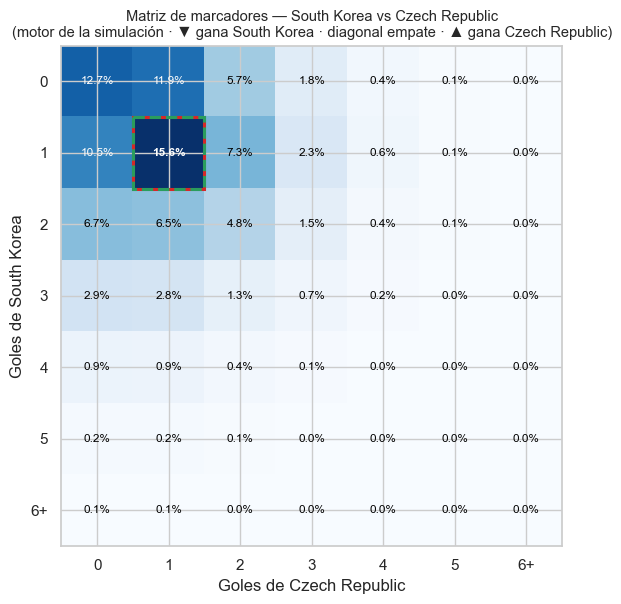

  🇲🇽 Mexico vs 🇧🇷 Brazil   —   cancha: localía de Mexico (anfitrión del Mundial)
Perfil del cruce (Mexico − Brazil), las 3 variables del modelo:
   Elo               -84.1    (1985 vs 2069)
   Valor plantel     -2.35    (€111M vs €1,164M, escala log)
   Head-to-head      -0.95    (42 duelos previos desde 1872)

Probabilidades del clasificador (validado en 2025-26):
   Mexico: 23.7%   |   Empate: 34.1%   |   Brazil: 42.2%
   Si es eliminatoria (prórroga/penales incl.): avanza Mexico 35.9% / Brazil 64.1%

Goles esperados (Poisson): 🇲🇽 Mexico 0.94 — 1.30 🇧🇷 Brazil
Marcadores más probables (motor de la simulación):
   1-1 (15.7%)   0-1 (13.0%)   0-0 (12.8%)   1-0 (8.8%)   0-2 (8.5%)

🎲 Simulación de ejemplo: Mexico 1-0 Brazil



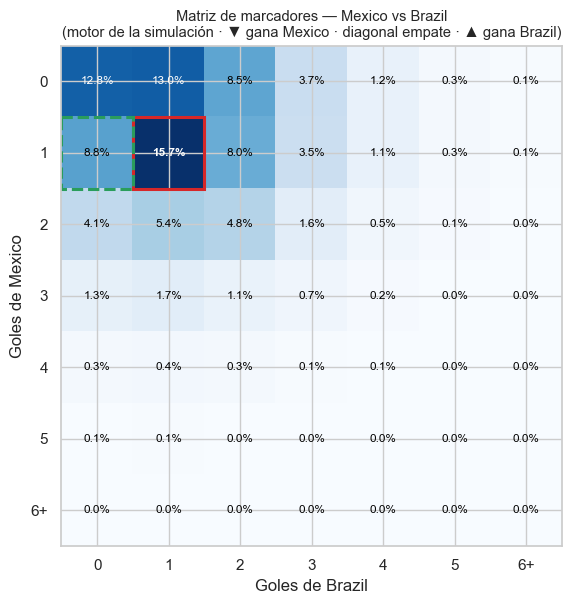

  Chile vs 🇦🇷 Argentina   —   cancha: localía de Chile
Perfil del cruce (Chile − Argentina), las 3 variables del modelo:
   Elo              -395.6    (1794 vs 2189)
   Valor plantel     -2.43    (€75M vs €856M, escala log)
   Head-to-head      -1.26    (91 duelos previos desde 1872)

Probabilidades del clasificador (validado en 2025-26):
   Chile: 7.1%   |   Empate: 22.1%   |   Argentina: 70.9%
   Si es eliminatoria (prórroga/penales incl.): avanza Chile 9.1% / Argentina 90.9%

Goles esperados (Poisson): Chile 0.52 — 2.38 🇦🇷 Argentina
Marcadores más probables (motor de la simulación):
   0-2 (14.1%)   0-1 (11.8%)   0-3 (11.1%)   1-1 (10.2%)   0-0 (8.3%)

🎲 Simulación de ejemplo: Chile 0-3 Argentina



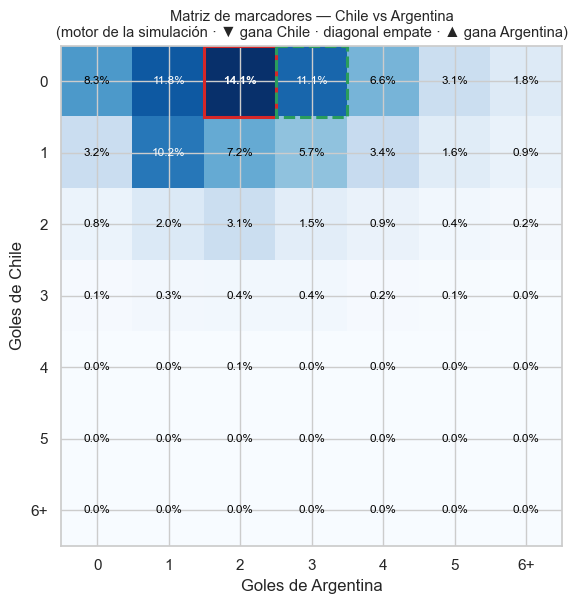

In [45]:
def h2h_par(a, b):
    '''H2H histórico para cualquier par: (promedio de dif. de gol desde la perspectiva de a, nº duelos).'''
    mm = hist[((hist.home_team == a) & (hist.away_team == b)) | ((hist.home_team == b) & (hist.away_team == a))]
    if len(mm) == 0:
        return 0.0, 0
    d = np.where(mm.home_team == a, mm.home_score - mm.away_score, mm.away_score - mm.home_score)
    return float(d.mean()), int(len(mm))


def _features_par(a, b):
    '''Las 11 candidatas para cualquier par de selecciones (h2h al vuelo, sirve fuera de los 48).'''
    sa, sb = states.loc[a], states.loc[b]
    return pd.DataFrame([{
        'elo_diff': sa.elo - sb.elo,
        'squad_value_diff': np.log(sa.squad_value) - np.log(sb.squad_value),
        'ea_overall_diff': sa.ea_overall - sb.ea_overall,
        'h2h_diff': h2h_par(a, b)[0],
        'goles_anotados_diff': sa.goles_anotados_avg - sb.goles_anotados_avg,
        'goles_recibidos_diff': sa.goles_recibidos_avg - sb.goles_recibidos_avg,
        'tiros_diff': sa.tiros_avg - sb.tiros_avg,
        'tiros_arco_diff': sa.tiros_arco_avg - sb.tiros_arco_avg,
        'corners_diff': sa.corners_avg - sb.corners_avg,
        'posesion_diff': sa.posesion_avg - sb.posesion_avg,
        'faltas_diff': sa.faltas_avg - sb.faltas_avg,
    }])


def versus(equipo1, equipo2, cancha='auto', semilla=None, matriz=True):
    '''Pronóstico detallado de un partido entre dos selecciones cualquiera.
       cancha: 'auto' | 'neutral' | '1' (local el 1°) | '2' (local el 2°).
       matriz: si True, dibuja la matriz de probabilidad de cada marcador exacto.'''
    for t in (equipo1, equipo2):
        if t not in states.index:
            parecidos = [s for s in states.index if t.lower() in s.lower()][:5]
            raise ValueError(f"'{t}' no está en team_states. ¿Quizás quisiste decir: {parecidos}?")
    a, b = equipo1, equipo2
    pa = final_model.predict_proba(_features_par(a, b)[FEATS_BEST])[0]
    pb = final_model.predict_proba(_features_par(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])   # perspectiva: [gana a, empate, gana b]
    vb = np.array([pb[0], pb[1], pb[2]])
    if cancha == '1':
        p, desc = va, f'localía de {a}'
    elif cancha == '2':
        p, desc = vb, f'localía de {b}'
    elif cancha == 'auto' and a in ANFITRIONES and b not in ANFITRIONES:
        p, desc = va, f'localía de {a} (anfitrión del Mundial)'
    elif cancha == 'auto' and b in ANFITRIONES and a not in ANFITRIONES:
        p, desc = vb, f'localía de {b} (anfitrión del Mundial)'
    else:
        p, desc = (va + vb) / 2, 'neutral'

    la, lb = lambdas_elo(a, b)
    g = np.arange(GRID_MAX + 1)
    grid = np.outer(poisson.pmf(g, la), poisson.pmf(g, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    masks = (gi > gj, gi == gj, gi < gj)
    mix = sum(p[k] * (grid * mk) / (grid * mk).sum() for k, mk in enumerate(masks))

    sa, sb = states.loc[a], states.loc[b]
    h2h_v, n_duelos = h2h_par(a, b)
    flag_a = FLAGS.get(a, '') + ' ' if a in FLAGS else ''
    flag_b = FLAGS.get(b, '') + ' ' if b in FLAGS else ''
    print('=' * 66)
    print(f'  {flag_a}{a} vs {flag_b}{b}   —   cancha: {desc}')
    print('=' * 66)
    print(f'Perfil del cruce ({a} − {b}), las 3 variables del modelo:')
    print(f'   Elo            {sa.elo - sb.elo:+8.1f}    ({sa.elo:.0f} vs {sb.elo:.0f})')
    print(f'   Valor plantel  {np.log(sa.squad_value) - np.log(sb.squad_value):+8.2f}    '
          f'(€{sa.squad_value / 1e6:,.0f}M vs €{sb.squad_value / 1e6:,.0f}M, escala log)')
    print(f'   Head-to-head   {h2h_v:+8.2f}    ({n_duelos} duelos previos desde 1872)')
    print(f'\nProbabilidades del clasificador (validado en 2025-26):')
    print(f'   {a}: {p[0]:.1%}   |   Empate: {p[1]:.1%}   |   {b}: {p[2]:.1%}')
    pkA = p[0] + p[1] * p[0] / (p[0] + p[2])
    print(f'   Si es eliminatoria (prórroga/penales incl.): avanza {a} {pkA:.1%} / {b} {1 - pkA:.1%}')
    print(f'\nGoles esperados (Poisson): {flag_a}{a} {la:.2f} — {lb:.2f} {flag_b}{b}')
    flat = mix.ravel(); top = flat.argsort()[::-1][:5]
    print('Marcadores más probables (motor de la simulación):')
    print('   ' + '   '.join(f'{ix // (GRID_MAX + 1)}-{ix % (GRID_MAX + 1)} ({flat[ix]:.1%})' for ix in top))
    r = np.random.default_rng(semilla) if semilla is not None else rng
    u = r.random(); resu = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)
    cond = (grid * masks[resu]).ravel(); cond = cond / cond.sum()
    ga_, gb_ = divmod(int(np.searchsorted(np.cumsum(cond), r.random())), GRID_MAX + 1)
    print(f'\n🎲 Simulación de ejemplo: {a} {ga_}-{gb_} {b}\n')

    if matriz:
        m = 6   # mostramos 0..5 y agregamos las colas en '6+'
        M = np.zeros((m + 1, m + 1))
        M[:m, :m] = mix[:m, :m]
        M[m, :m] = mix[m:, :m].sum(axis=0)
        M[:m, m] = mix[:m, m:].sum(axis=1)
        M[m, m] = mix[m:, m:].sum()
        fig, ax = plt.subplots(figsize=(7.4, 6.2))
        ax.imshow(M, cmap='Blues')
        etiq = [str(i) for i in range(m)] + ['6+']
        ax.set_xticks(range(m + 1)); ax.set_xticklabels(etiq)
        ax.set_yticks(range(m + 1)); ax.set_yticklabels(etiq)
        ax.set_xlabel(f'Goles de {b}'); ax.set_ylabel(f'Goles de {a}')
        ax.set_title(f'Matriz de marcadores — {a} vs {b}\n'
                     f'(motor de la simulación · ▼ gana {a} · diagonal empate · ▲ gana {b})', fontsize=10.5)
        imax, jmax = np.unravel_index(M.argmax(), M.shape)
        for i in range(m + 1):
            for j in range(m + 1):
                ax.text(j, i, f'{M[i, j]:.1%}', ha='center', va='center', fontsize=8.5,
                        color='white' if M[i, j] > M.max() * 0.6 else 'black',
                        fontweight='bold' if (i, j) == (imax, jmax) else 'normal')
        # rojo = marcador más probable; verde punteado = el sorteado en la simulación de ejemplo
        ax.add_patch(plt.Rectangle((jmax - 0.5, imax - 0.5), 1, 1, fill=False, edgecolor='#d62728', lw=2.2))
        ax.add_patch(plt.Rectangle((min(gb_, m) - 0.5, min(ga_, m) - 0.5), 1, 1,
                                   fill=False, edgecolor='#2a9d5c', lw=2.2, ls='--'))
        plt.tight_layout(); plt.show()


versus('South Korea', 'Czech Republic')
versus('Mexico', 'Brazil')                  # anfitrión -> localía automática
versus('Chile', 'Argentina', cancha='1')    # también sirve para selecciones fuera del Mundial

## 10 · Modelo Poisson de goles

Ajuste de un modelo de Poisson para predecir los goles anotados por cada equipo de forma independiente utilizando las mismas 3 variables predictoras. Permite obtener directamente probabilidades para cada marcador exacto.

In [ ]:
# Goles reales de cada partido (merge 1:1 con espn_stats por fecha+equipos)
goles = pd.read_csv('espn_stats.csv', parse_dates=['fecha'])[['fecha', 'local', 'visita', 'goles_local', 'goles_visita']]
datag = data.merge(goles, on=['fecha', 'local', 'visita'], how='left')
dtr = datag[datag.fecha < CORTE_TEST]; dte = datag[datag.fecha >= CORTE_TEST]

largo_tr = pd.concat([
    dtr[FINAL].assign(g=dtr.goles_local.values),
    (-dtr[FINAL]).assign(g=dtr.goles_visita.values)], ignore_index=True)
pois = sm.GLM(largo_tr['g'], sm.add_constant(largo_tr[FINAL]), family=sm.families.Poisson()).fit()
b0 = pois.params['const']; bet = pois.params[FINAL].values
print(pois.summary().tables[1])

def lambdas_final(fr):
    s = float(np.dot(bet, fr)); return np.exp(b0 + s), np.exp(b0 - s)

def wdl(li, lj, m=10):
    # filas = goles del local (i), columnas = goles de la visita (j)
    Mx = np.outer(poisson.pmf(np.arange(m + 1), li), poisson.pmf(np.arange(m + 1), lj))
    return np.array([np.triu(Mx, 1).sum(), np.trace(Mx), np.tril(Mx, -1).sum()])   # [derrota (j>i), empate, victoria (i>j)]

pp = np.array([wdl(*lambdas_final(r)) for r in dte[FINAL].values])
pp /= pp.sum(1, keepdims=True)
pl = pipe.predict_proba(dte[FINAL]); yv_ = dte.resultado.values
pe = (pl + pp) / 2   # ensamble: promedio de las probabilidades de ambas familias
comp = pd.DataFrame({'Modelo': ['Logística multinomial', 'Poisson de goles', 'Ensamble (promedio de ambos)'],
                     'Accuracy': [accuracy_score(yv_, P.argmax(1)) for P in (pl, pp, pe)],
                     'LogLoss': [log_loss(yv_, P) for P in (pl, pp, pe)],
                     'RPS': [rps(P, yv_) for P in (pl, pp, pe)]}).set_index('Modelo')
display(comp.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen').set_properties(**{'font-family': 'Inter, sans-serif', 'padding': '10px 14px', 'font-size': '13px'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e293b'), ('color', 'white'), ('padding', '10px 14px')]}]))

print('Marcadores más probables (Poisson, estado actual de los equipos):')
for i, j in [('Spain', 'Argentina'), ('France', 'Brazil'), ('England', 'Germany')]:
    fr = features_cruce(i, j)[FINAL].values[0]
    li, lj = lambdas_final(fr)
    m = np.outer(poisson.pmf(np.arange(7), li), poisson.pmf(np.arange(7), lj))
    x, y_ = np.unravel_index(m.argmax(), m.shape)
    print(f'  {i} {x}-{y_} {j}  ({m[x, y_] * 100:.0f}% el marcador, λ: {li:.2f} - {lj:.2f})')

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0801      0.011      7.097      0.000       0.058       0.102
elo_diff             0.0016   5.94e-05     27.348      0.000       0.002       0.002
h2h_diff             0.0657      0.008      8.607      0.000       0.051       0.081
squad_value_diff     0.0144      0.006      2.265      0.023       0.002       0.027


,Accuracy,LogLoss,RPS
Modelo,,,
Logística multinomial,0.596200,0.851700,0.161600
Poisson de goles,0.598100,0.860400,0.164100
Ensamble (promedio de ambos),0.598100,0.852300,0.162100


Marcadores más probables (Poisson, estado actual de los equipos):
  Spain 1-1 Argentina  (13% el marcador, λ: 1.16 - 1.01)
  France 1-1 Brazil  (13% el marcador, λ: 1.17 - 1.01)
  England 1-0 Germany  (14% el marcador, λ: 1.28 - 0.91)


**Comparación predictiva:**
El modelo de Poisson y la clasificación multinomial ofrecen un rendimiento predictivo equivalente en términos de Log-Loss e índice RPS sobre el conjunto de test.

### 10.1 · El Mundial según la Poisson: simulación del torneo

Re-simulación del torneo completo utilizando el modelo de Poisson como motor exclusivo para la generación de marcadores y resultados de los partidos.

In [ ]:
# Poisson definitiva (TODOS los datos) y grillas por cruce
largo_full = pd.concat([
    datag[FINAL].assign(g=datag.goles_local.values),
    (-datag[FINAL]).assign(g=datag.goles_visita.values)], ignore_index=True)
pois_full = sm.GLM(largo_full['g'], sm.add_constant(largo_full[FINAL]), family=sm.families.Poisson()).fit()
b0f = pois_full.params['const']; betf = pois_full.params[FINAL].values

gidx = np.arange(GRID_MAX + 1)
PROBS_P, SCORE_P = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    fr = features_cruce(a, b)[FINAL].values[0].astype(float)
    s = float(np.dot(betf, fr))
    la, lb = np.exp(b0f + s), np.exp(b0f - s)
    grid = np.outer(poisson.pmf(gidx, la), poisson.pmf(gidx, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    PROBS_P[(a, b)] = np.array([(grid * (gi > gj)).sum(), np.trace(grid), (grid * (gi < gj)).sum()])
    SCORE_P[(a, b)] = np.cumsum(grid.ravel())


def simular_partido_poisson(a, b, eliminatoria=False):
    '''Motor Poisson puro: el marcador se sortea de la grilla; el V/E/D emerge de los goles.'''
    ga, gb = divmod(int(np.searchsorted(SCORE_P[(a, b)], rng.random())), GRID_MAX + 1)
    if ga > gb: return ga, gb, a
    if gb > ga: return ga, gb, b
    if eliminatoria:
        p = PROBS_P[(a, b)]
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


rng = np.random.default_rng(SEED)   # misma semilla que el Monte Carlo del clasificador
cont_p = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial(partido=simular_partido_poisson)
    cont_p[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont_p[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont_p[t]['semi'] += 1
    for t in set(r['a_octavos']): cont_p[t]['octavos'] += 1

res_pois = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t],
                          'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                          'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                         for t, c in cont_p.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_pois.to_csv('probabilidades_torneo_poisson.csv', index=False)
print(f'{N_SIMS:,} Mundiales simulados con motor Poisson. Guardado: probabilidades_torneo_poisson.csv\n')
res_pois.head(12).style.format({'P_campeon': '{:.1%}', 'P_final': '{:.1%}', 'P_semi': '{:.1%}', 'P_octavos': '{:.1%}'})

10,000 Mundiales simulados con motor Poisson. Guardado: probabilidades_torneo_poisson.csv



,Selección,grupo,P_campeon,P_final,P_semi,P_octavos
0,Spain,H,27.6%,39.9%,52.9%,81.8%
1,Argentina,J,18.5%,31.0%,44.7%,71.0%
2,France,I,11.2%,20.3%,37.1%,75.2%
3,England,L,8.9%,16.5%,29.4%,70.8%
4,Brazil,C,6.6%,13.7%,27.7%,67.4%
5,Portugal,K,3.8%,9.6%,19.2%,62.0%
6,Colombia,K,3.6%,8.8%,17.1%,58.0%
7,Germany,E,2.6%,6.7%,16.7%,62.4%
8,Netherlands,F,2.4%,6.5%,16.0%,50.8%
9,Ecuador,E,1.9%,5.3%,13.6%,57.0%


### 10.2 · Comparativa de simulaciones: Clasificador vs. Poisson

Correlación de P(campeón) entre motores: Pearson 0.999 | Spearman (orden) 0.967



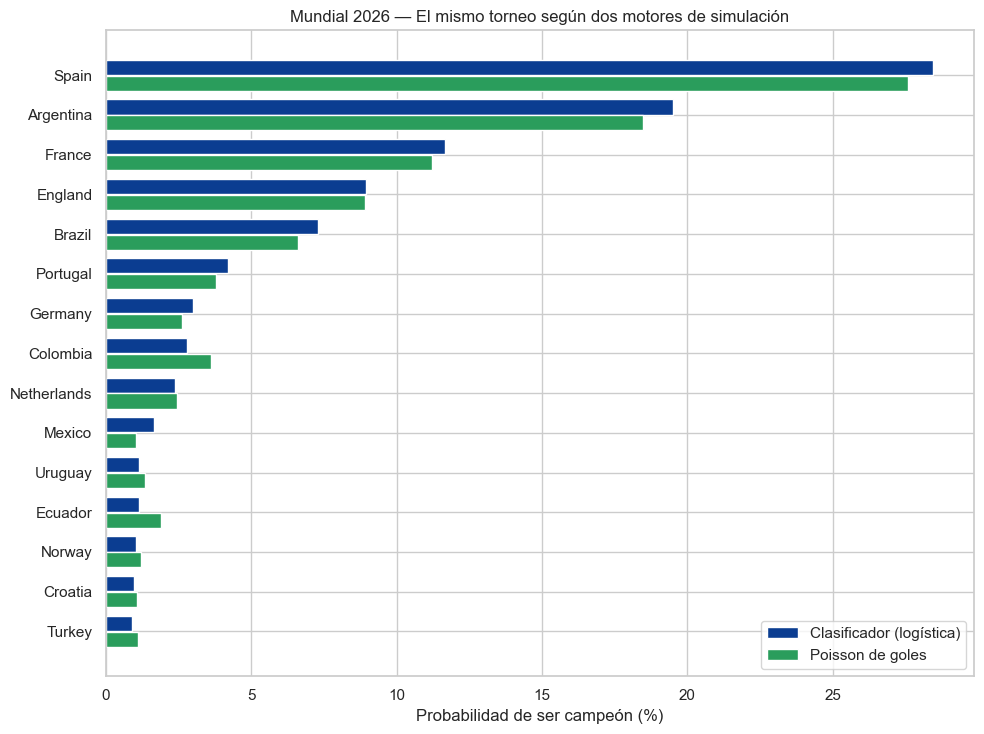

Mayores diferencias entre motores (P campeón):


,Selección,grupo,P_campeon_logit,P_campeon_poisson,dif (logit − poisson)
0,Argentina,J,0.1951,0.1847,0.0104
1,Spain,H,0.2843,0.2757,0.0086
2,Colombia,K,0.0278,0.0363,-0.0085
3,Ecuador,E,0.0114,0.0191,-0.0077
4,Brazil,C,0.0730,0.0661,0.0069
5,Mexico,A,0.0166,0.0105,0.0061
6,Morocco,C,0.0089,0.0145,-0.0056
7,France,I,0.1167,0.1121,0.0046


In [ ]:
from scipy.stats import spearmanr

cmp_ = res_mc[['Selección', 'grupo', 'P_campeon', 'P_semi']].merge(
    res_pois[['Selección', 'P_campeon', 'P_semi']], on='Selección', suffixes=('_logit', '_poisson'))
cmp_['dif (logit − poisson)'] = cmp_.P_campeon_logit - cmp_.P_campeon_poisson

pe_ = cmp_.P_campeon_logit.corr(cmp_.P_campeon_poisson)
sp_ = spearmanr(cmp_.P_campeon_logit, cmp_.P_campeon_poisson).statistic
print(f'Correlación de P(campeón) entre motores: Pearson {pe_:.3f} | Spearman (orden) {sp_:.3f}\n')

top = cmp_.sort_values('P_campeon_logit', ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7.5))
ypos = np.arange(len(top))
ax.barh(ypos + 0.2, top.P_campeon_logit * 100, height=0.38, color='#0b3d91', label='Clasificador (logística)')
ax.barh(ypos - 0.2, top.P_campeon_poisson * 100, height=0.38, color='#2a9d5c', label='Poisson de goles')
ax.set_yticks(ypos); ax.set_yticklabels(top['Selección'])
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 — El mismo torneo según dos motores de simulación')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print('Mayores diferencias entre motores (P campeón):')
dif = cmp_.reindex(cmp_['dif (logit − poisson)'].abs().sort_values(ascending=False).index).head(8)
display(style_table(dif[['Selección', 'grupo', 'P_campeon_logit', 'P_campeon_poisson', 'dif (logit − poisson)']].reset_index(drop=True)))

**Conclusiones de la comparativa:**
Ambas metodologías convergen en un orden de favoritos altamente correlacionado. Las diferencias principales radican en la ventaja de localía (la Poisson se entrenó de forma simétrica) y en la distribución del empate en partidos muy desiguales.

## 11 · Conclusiones y limitaciones

* **Metodología anti-fuga:** Implementación de variables point-in-time y evaluación mediante división temporal estricta en el periodo 2025–2026.
* **Robustez de variables:** Coherencia en la selección de 3 variables (`elo_diff`, `h2h_diff`, `squad_value_diff`) en modelos de búsqueda secuencial y regularización Lasso.
* **Consistencia:** Convergencia predictiva entre el clasificador multinomial y el modelo Poisson.
* **Limitaciones:** Los estados de forma de las selecciones se asumen constantes a partir de junio de 2026 (sin incorporar convocatorias definitivas ni lesiones del torneo).